<a href="https://colab.research.google.com/github/lia-ang/measles_model/blob/main/code/Measles_Model_UpdatedSCData_UpdatedParameters_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import statistics
from scipy.optimize import curve_fit
from scipy.stats import truncnorm

In [21]:
#import os

# Define default path for saving figures
#FIGURE_DIR = "measles_model/simulation"

# Create the directory if it doesn't exist
#os.makedirs(FIGURE_DIR, exist_ok=True)

In [22]:
#pulling data from repository
url = "https://raw.githubusercontent.com/lia-ang/measles_model/refs/heads/main/data/S.Carolina_case.csv"
GC = pd.read_csv(url)

y_case = GC['Cumulative Cases'].to_numpy()
x_case = GC['t'].to_numpy()

In [23]:
##ALTERED FOR PROJECT
#define paramters
#VE for three age group epsilon
epsilon=[0.93, 0.97, 0.97]

#Exposed to infectious rate, sigma
sigma_ub=float(1/7)
sigma_lb=float(1/10) #updated to WHO data
sigma_pe=(sigma_ub+sigma_lb)/2

#I to R rate, gamma 1 #updated to WHO data for until all symptoms fade
gamma1_ub=float(1/15)
gamma1_lb=float(1/27)
gamma1_pe=(gamma1_ub+gamma1_lb)/2

#Changed to IDR
IDR_ub=[gamma1_ub*(0.3)/(1-(0.3)),gamma1_ub*(0.3/13)/(1-(0.3)),gamma1_ub*(0.3)/(1-(0.3))]
IDR_lb=[gamma1_lb*(0.1)/(1-(0.1)),gamma1_lb*(0.1/13)/(1-(0.1)),gamma1_lb*(0.1)/(1-(0.1))]
IDR_pe=[(IDR_ub[0]+IDR_lb[0])/2,(IDR_ub[1]+IDR_lb[1])/2,(IDR_ub[2]+IDR_lb[2])/2]

#contact matrix
CM=[[1.4101, 2.5282, 4.91],[ 0.9290, 11.0091, 6.0771], [0.4884, 1.6387, 8.8461]]

In [24]:
def computerate(i, CWW, aW, I, Ni):
    rate = 0
    for n in range(3):
        rate += aW*CWW[i][n]*(np.sum(max(0, I[n]))/Ni[n])
        #return 1
    return rate

In [25]:
#Import state data

#Total population at age group 0-4, 5-19, 20+ N
N = [289529, 991341, 4015315]
V = [186457, 904103, 3661968]
theta=1.04

In [26]:
def sim_fit_contact(x, beta0, beta1, beta2, con0, con1, con2):
    Nd = 200
    dt = 1
    # Updated to use ** for exponentiation instead of ^
    N = [289529, 991341, 4015315]  # population per age group
    V = [186457, 904103, 3661968]  # vaccinated per age group
    theta = 1.04  # vaccination flow
    rho = 0.891 # underreporting rate

    S1 = np.zeros(3)
    S2 = np.zeros(3)
    V1 = np.zeros(3)
    V2 = np.zeros(3)
    E = np.zeros(3)
    I = np.zeros(3)
    R = np.zeros(3)
    D = np.zeros(3)

    S1_new = np.zeros(3)
    S2_new = np.zeros(3)
    V1_new = np.zeros(3)
    V2_new = np.zeros(3)
    E_new = np.zeros(3)
    I_new = np.zeros(3)
    R_new = np.zeros(3)
    D_new = np.zeros(3)

    cumcase = np.zeros(Nd)
    cumcase0 = np.zeros(Nd)
    cumcase1 = np.zeros(Nd)
    cumcase2 = np.zeros(Nd)

    x_contact = [con0, con1, con2]
    case_count = case_count0 = case_count1 = case_count2 = 0

    for n in range(3):
        contact_rate = x_contact[n]
        S_total = N[n] - V[n]
        S1[n] = S_total * contact_rate
        S2[n] = S_total * (1 - contact_rate)
        V1[n] = V[n] * contact_rate
        V2[n] = V[n] * (1 - contact_rate)

    I[1] = 1
    sig = sigma_pe
    gam1 = gamma1_pe
    IDR = IDR_pe

    for tt in range(Nd):
        for i in range(3):
            beta = [beta0, beta1, beta2][i]
            eps = epsilon[i]
            idr = IDR[i]
            the = theta if i == 0 else 0

            N_dyn = S1 + E + I + R + D + V1
            lambda_i = beta * computerate(i, CM, 1, I, N_dyn)

            S1_new[i] = max(0, S1[i] - lambda_i * S1[i] - the*x_contact[i])
            S2_new[i] = S2[i] - the*(1-x_contact[i])
            V1_new[i] = V1[i] - lambda_i * V1[i] * (1 - eps) + the*x_contact[i]
            V2_new[i] = V2[i] + the*(1-x_contact[i])

            new_exposed = lambda_i * S1[i] + lambda_i * V1[i] * (1 - eps)
            E_new[i] = E[i] + new_exposed - sig * E[i]
            I_new[i] = I[i] + sig * E[i] - (idr + gam1) * I[i]
            R_new[i] = R[i] + gam1 * I[i]
            D_new[i] = D[i] + idr * I[i]

            inc = sig * E[i] * rho
            case_count += inc
            cumcase[tt] = case_count
            if i == 0:
                case_count0 += inc
                cumcase0[tt] = case_count0
            elif i == 1:
                case_count1 += inc
                cumcase1[tt] = case_count1
            else:
                case_count2 += inc
                cumcase2[tt] = case_count2

        S1, S2, V1, V2, E, I, R, D = S1_new.copy(), S2_new.copy(), V1_new.copy(), V2_new.copy(), E_new.copy(), I_new.copy(), R_new.copy(), D_new.copy()

    t_indices = GC['t'].values
    return np.concatenate((cumcase0[t_indices], cumcase1[t_indices], cumcase2[t_indices]))

In [27]:
from scipy.optimize import curve_fit

# Age-specific splits using proportions
y_case0 = y_case * 0.34
y_case1 = y_case * 0.48
y_case2 = y_case * 0.18

# Combine all into one array to match sim_fit output
ydata = np.concatenate((y_case0, y_case1, y_case2))
xdata = np.arange(len(ydata))

# Define initial guesses and bounds
initial_guess = [0.3, 0.3, 0.3, 0.7, 0.7, 0.7]  # beta0, beta1, beta2, x_contact
lower_bounds = [0, 0, 0, 0, 0, 0]
upper_bounds = [10.0, 10.0, 10.0, 1, 1, 1]

# Curve fitting
popt, pcov = curve_fit(
    sim_fit_contact,
    xdata,
    ydata,
    p0=initial_guess,
    bounds=(lower_bounds, upper_bounds),
    maxfev=10000
)

# Output estimated parameters
print("Estimated beta0, beta1, beta2, x_contact:")
print(popt)

Estimated beta0, beta1, beta2, x_contact:
[4.23783685e-04 1.55074305e-01 8.66328351e-05 9.99994931e-01
 2.33536454e-03 1.00000000e+00]


In [28]:
x1,x2,x3= popt[0],popt[1],popt[2]
y1,y2,y3= popt[3],popt[4],popt[5]
z1,z2,z3= pcov[0][0],pcov[1][1],pcov[2][2]
V_base=[186457, 904103, 3661968]
V_low=[1636, 3735, 11616]
V_high=[2283, 5206, 13334]
print(x1,x2,x3,y1,y2,y3,z1,z2,z3)

0.00042378368487985444 0.1550743052449978 8.663283511281606e-05 0.9999949311367362 0.0023353645435890734 0.9999999999999999 0.024827128389243478 5.904600081077269e-05 0.005007427511643308


In [29]:
def sim_det(x, beta0, beta1, beta2, std0, std1, std2, V_input, con0, con1, con2):
    Nd = 162 # Changed from 150 to accommodate indices up to 161
    dt = 1
    N = [289529, 991341, 4015315]
    V = V_input
    theta = 1.04

    # normal distribution for underreporting (mean, 89.1%; 95% credible interval (CrI), 79.4 to 99.2%)
    mu = 0.891
    sigma = 0.0505
    a, b = (0 - mu) / sigma, (1 - mu) / sigma  # bounds for truncation
    rho = truncnorm.rvs(a, b, loc=mu, scale=sigma)

    S1 = np.zeros([3])
    S2 = np.zeros([3])
    V1 = np.zeros([3])
    V2 = np.zeros([3])
    E = np.zeros([3])
    I = np.zeros([3])
    R = np.zeros([3])
    H = np.zeros([3])
    D = np.zeros([3])

    case_count = 0
    hosp_count = 0
    death_count = 0
    case_count0 = 0
    hosp_count0 = 0
    death_count0 = 0
    case_count1 = 0
    hosp_count1 = 0
    death_count1 = 0
    case_count2 = 0
    hosp_count2 = 0
    death_count2 = 0

    cumcase = np.zeros([Nd])
    cumhosp = np.zeros([Nd])
    cumdeath = np.zeros([Nd])
    cumcase0 = np.zeros([Nd])
    cumhosp0 = np.zeros([Nd])
    cumdeath0 = np.zeros([Nd])
    cumcase1 = np.zeros([Nd])
    cumhosp1 = np.zeros([Nd])
    cumdeath1 = np.zeros([Nd])
    cumcase2 = np.zeros([Nd])
    cumhosp2 = np.zeros([Nd])
    cumdeath2 = np.zeros([Nd])
    cumI = np.zeros([Nd])
    cumH = np.zeros([Nd])
    cumD = np.zeros([Nd])

    x_contact = [con0, con1, con2]

    for n in range(3):
        contact_rate = x_contact[n]
        S_total = N[n] - V[n]
        S1[n] = S_total * contact_rate
        S2[n] = S_total * (1 - contact_rate)
        v_total = V[n]
        V1[n] = v_total * contact_rate
        V2[n] = v_total * (1 - contact_rate)

    I[1] = 1

    for tt in range(int(Nd / dt)):
        np.random.seed()
        sig = sigma_pe
        gam1 = gamma1_pe
        gam2 = gamma2_pe
        IHR = IHR_pe
        HDR = HDR_pe

        S1_new = np.zeros([3])
        S2_new = np.zeros([3])
        E_new = np.zeros([3])
        I_new = np.zeros([3])
        R_new = np.zeros([3])
        H_new = np.zeros([3])
        D_new = np.zeros([3])
        V1_new = np.zeros([3])
        V2_new = np.zeros([3])

        for i in range(3):
            if i == 0:
                rnd = np.random.normal(0, std0, 1)
                beta = beta0
                eps = epsilon[0]
                ihr = IHR[0]
                hdr = HDR[0]
                the = theta
            elif i == 1:
                rnd = np.random.normal(0, std1, 1)
                beta = beta1
                eps = epsilon[1]
                ihr = IHR[1]
                hdr = HDR[1]
                the = 0
            else:
                beta = beta2
                eps = epsilon[2]
                ihr = IHR[2]
                hdr = HDR[2]
                the = 0

            N_dyn = S1 + E + I + R + H + D + V1
            N_sum = np.sum(S1 + S2 + E + I + R + H + D + V1 + V2)
            foi = beta * computerate(i, CM, 1, I, N_dyn)

            #actual_theta = min(the, S1[i])
            S1_new[i] = max(0,S1[i] - foi * S1[i] - the*x_contact[i])
            S2_new[i] = S2[i] - the*(1-x_contact[i])# no contact
            V1_new[i] = V1[i] - foi * V1[i] * (1 - eps) + the*x_contact[i]
            V2_new[i] = V2[i] + the*(1-x_contact[i]) # static if no movement

            E_new[i] = E[i] + foi * S1[i] + foi * V1[i] * (1 - eps) - sig * E[i]
            I_new[i] = I[i] + sig * E[i] - (ihr + gam1) * I[i]
            case_count=case_count+sig*E[i]* rho
            cumcase[tt] = case_count

            H_new[i] = H[i] + ihr * I[i] - (hdr + gam2) * H[i]
            hosp_count=hosp_count+ihr * I[i] * rho
            cumhosp[tt] = hosp_count

            R_new[i] = R[i] + gam1 * I[i] + gam2 * H[i]
            D_new[i] = D[i] + hdr * H[i]
            death_count=death_count+hdr * H[i] * rho
            cumdeath[tt] = death_count

            if i == 0:
                case_count0 = case_count0+sig * E[i] * rho
                cumcase0[tt] = case_count0
                hosp_count0 = hosp_count0+ihr * I[i] * rho
                cumhosp0[tt] = hosp_count0
                death_count0 = death_count0+hdr * H[i] * rho
                cumdeath0[tt] = death_count0
            elif i == 1:
                case_count1 = case_count1+sig * E[i] * rho
                cumcase1[tt] = case_count1
                hosp_count1 = hosp_count1+ihr * I[i] * rho
                cumhosp1[tt] = hosp_count1
                death_count1 = death_count1+hdr * H[i] * rho
                cumdeath1[tt] = death_count1
            elif i == 2:
                case_count2 = case_count2+sig * E[i] * rho
                cumcase2[tt] = case_count2
                hosp_count2 = hosp_count2+ihr * I[i] * rho
                cumhosp2[tt] = hosp_count2
                death_count2 = death_count2+hdr * H[i] * rho
                cumdeath2[tt] = death_count2

        S1 = S1_new.copy()
        S2 = S2_new.copy()
        V1 = V1_new.copy()
        V2 = V2_new.copy()
        E = E_new.copy()
        I = I_new.copy()
        H = H_new.copy()
        R = R_new.copy()
        D = D_new.copy()

        cumI[tt] = np.sum(I)
        cumH[tt] = np.sum(H)
        cumD[tt] = np.sum(D)

        print(f"tt={tt}, case_count0={case_count0}, delta={sig * E[0] * rho}, E={E[0]}, S1={S1[0]}, N={N_sum}")

    t_subset = GC['t'].iloc[1:25].values
    case_series = cumcase[t_subset]

    p0 = 100 * sum(cumcase0) / sum(cumcase)
    p1 = 100 * sum(cumcase1) / sum(cumcase)
    p2 = 100 * sum(cumcase2) / sum(cumcase)

    fit_case = np.concatenate((case_series, [p0, p1, p2]))

    return fit_case, cumI, cumH, cumD, cumcase, cumhosp, cumdeath, cumcase0, cumhosp0, cumcase1, cumhosp1, cumcase2, cumhosp2


In [30]:
def sim_scenario(V_sce):
    Nsim = 200
    Nd = 162 # Updated from 145 to match sim_sto and the dataset

    x1, x2, x3 = popt[0], popt[1], popt[2]
    y1, y2, y3= popt[3],popt[4],popt[5]
    z1, z2, z3 = pcov[0][0], pcov[1][1], pcov[2][2]

    new_Inf = np.zeros([Nd, Nsim])
    new_Hosp = np.zeros([Nd, Nsim])
    new_Death = np.zeros([Nd, Nsim])
    cum_Inf = np.zeros([Nd, Nsim])
    cum_Hosp = np.zeros([Nd, Nsim])
    cum_Death = np.zeros([Nd, Nsim])
    cum_Inf0 = np.zeros([Nd, Nsim])
    cum_Inf1 = np.zeros([Nd, Nsim])
    cum_Inf2 = np.zeros([Nd, Nsim])
    cum_Hosp0 = np.zeros([Nd, Nsim])
    cum_Hosp1 = np.zeros([Nd, Nsim])
    cum_Hosp2 = np.zeros([Nd, Nsim])

    for i in range(Nsim):
        fit_case, cumI, cumH, cumD, cumcase, cumhosp, cumdeath, cumcase0, cumhosp0, cumcase1, cumhosp1, cumcase2, cumhosp2 = sim_sto(
            0, x1, x2, x3, z1, z2, z3, V_sce, y1, y2, y3)
        new_Inf[:, i] = cumI
        new_Hosp[:, i] = cumH
        new_Death[:, i] = cumD
        cum_Inf[:, i] = cumcase
        cum_Hosp[:, i] = cumhosp
        cum_Death[:, i] = cumdeath
        cum_Inf0[:, i] = cumcase0
        cum_Inf1[:, i] = cumcase1
        cum_Inf2[:, i] = cumcase2
        cum_Hosp0[:, i] = cumhosp0
        cum_Hosp1[:, i] = cumhosp1
        cum_Hosp2[:, i] = cumhosp2

    percentiles = [0, 1, 2.5, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50,
                   55, 60, 65, 70, 75, 80, 85, 90, 95, 97.5, 99, 100]
    new_Inf_p = np.percentile(new_Inf, percentiles, axis=1).T
    new_Hosp_p = np.percentile(new_Hosp, percentiles, axis=1).T
    new_Death_p = np.percentile(new_Death, percentiles, axis=1).T
    cum_Inf_p = np.percentile(cum_Inf, percentiles, axis=1).T
    cum_Hosp_p = np.percentile(cum_Hosp, percentiles, axis=1).T
    cum_Death_p = np.percentile(cum_Death, percentiles, axis=1).T
    cum_Inf0_p = np.percentile(cum_Inf0, percentiles, axis=1).T
    cum_Inf1_p = np.percentile(cum_Inf1, percentiles, axis=1).T
    cum_Inf2_p = np.percentile(cum_Inf2, percentiles, axis=1).T
    cum_Hosp0_p = np.percentile(cum_Hosp0, percentiles, axis=1).T
    cum_Hosp1_p = np.percentile(cum_Hosp1, percentiles, axis=1).T
    cum_Hosp2_p = np.percentile(cum_Hosp2, percentiles, axis=1).T

    return (new_Inf_p, new_Hosp_p, new_Death_p,
            cum_Inf,cum_Inf_p, cum_Hosp_p, cum_Death_p,
            cum_Inf0_p, cum_Inf1_p, cum_Inf2_p,
            cum_Hosp0_p, cum_Hosp1_p, cum_Hosp2_p)

In [31]:
def sim_sto(x, beta0, beta1, beta2, std0, std1, std2, V_input, con0, con1, con2):
    Nd = 162
    dt = 1
    N = [289529, 991341, 4015315]
    V = V_input
    theta = 1.04

    mu = 0.891
    sigma = 0.0505
    a, b = (0 - mu) / sigma, (1 - mu) / sigma
    rho = truncnorm.rvs(a, b, loc=mu, scale=sigma)

    S1, S2, V1, V2, E, I, R, D = [np.zeros(3) for _ in range(8)]
    S1_new, S2_new, V1_new, V2_new, E_new, I_new, R_new, D_new = [np.zeros(3) for _ in range(8)]

    case_count = case_count0 = case_count1 = case_count2 = 0
    cumcase, cumcase0, cumcase1, cumcase2, cumI, cumD = [np.zeros(Nd) for _ in range(6)]

    x_contact = [con0, con1, con2]
    for n in range(3):
        S_total = N[n] - V[n]
        S1[n] = S_total * x_contact[n]
        S2[n] = S_total * (1 - x_contact[n])
        V1[n] = V[n] * x_contact[n]
        V2[n] = V[n] * (1 - x_contact[n])

    I[1] = 1

    for tt in range(Nd):
        sig = np.random.uniform(sigma_lb, sigma_ub)
        gam1 = np.random.uniform(gamma1_lb, gamma1_ub)
        IDR = [np.random.uniform(IDR_lb[i], IDR_ub[i]) for i in range(3)]

        for i in range(3):
            rnd = np.random.normal(0, [std0, std1, std2][i], 1)
            beta = np.clip([beta0, beta1, beta2][i] + 2 * rnd, 0, 5)
            eps = epsilon[i]
            idr = IDR[i]
            the = theta if i == 0 else 0

            N_dyn = S1 + E + I + R + D + V1
            foi = beta * computerate(i, CM, 1, I, N_dyn)

            S1_new[i] = max(0, S1[i] - foi * S1[i] - the*x_contact[i])
            S2_new[i] = S2[i] - the*(1-x_contact[i])
            V1_new[i] = V1[i] - foi * V1[i] * (1 - eps) + the*x_contact[i]
            V2_new[i] = V2[i] + the*(1-x_contact[i])

            new_exposed = foi * S1[i] + foi * V1[i] * (1 - eps)
            E_new[i] = E[i] + new_exposed - sig * E[i]
            I_new[i] = I[i] + sig * E[i] - (idr + gam1) * I[i]
            R_new[i] = R[i] + gam1 * I[i]
            D_new[i] = D[i] + idr * I[i]

            inc = sig * E[i] * rho
            case_count += inc
            cumcase[tt] = case_count
            if i == 0: case_count0 += inc; cumcase0[tt] = case_count0
            elif i == 1: case_count1 += inc; cumcase1[tt] = case_count1
            elif i == 2: case_count2 += inc; cumcase2[tt] = case_count2

        S1, S2, V1, V2, E, I, R, D = S1_new.copy(), S2_new.copy(), V1_new.copy(), V2_new.copy(), E_new.copy(), I_new.copy(), R_new.copy(), D_new.copy()
        cumI[tt] = np.sum(I)
        cumD[tt] = np.sum(D)

    return None, cumI, None, cumD, cumcase, None, None, cumcase0, None, cumcase1, None, cumcase2, None

In [32]:
new_Inf_p_A, new_Hosp_p_A, new_Death_p_A, cum_Inf_A, cum_Inf_p_A, cum_Hosp_p_A, cum_Death_p_A, cum_Inf0_p_A, cum_Inf1_p_A, cum_Inf2_p_A, cum_Hosp0_p_A, cum_Hosp1_p_A, cum_Hosp2_p_A = sim_scenario(V_base)
new_Inf_p_B, new_Hosp_p_B, new_Death_p_B, cum_Inf_B, cum_Inf_p_B, cum_Hosp_p_B, cum_Death_p_B, cum_Inf0_p_B, cum_Inf1_p_B, cum_Inf2_p_B, cum_Hosp0_p_B, cum_Hosp1_p_B, cum_Hosp2_p_B = sim_scenario(V_low)
new_Inf_p_C, new_Hosp_p_C, new_Death_p_C, cum_Inf_C, cum_Inf_p_C, cum_Hosp_p_C, cum_Death_p_C, cum_Inf0_p_C, cum_Inf1_p_C, cum_Inf2_p_C, cum_Hosp0_p_C, cum_Hosp1_p_C, cum_Hosp2_p_C = sim_scenario(V_high)
print("Simulations updated with new IDR parameters.")

/tmp/ipykernel_1571/4245139291.py:44: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S1_new[i] = max(0, S1[i] - foi * S1[i] - the*x_contact[i])
/tmp/ipykernel_1571/4245139291.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V1_new[i] = V1[i] - foi * V1[i] * (1 - eps) + the*x_contact[i]
/tmp/ipykernel_1571/4245139291.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  E_new[i] = E[i] + new_exposed - sig * E[i]


Simulations updated with new IDR parameters.


In [33]:
# Checking the current value of Nsim and the shape of the simulation results
print(f"Nsim is currently set to: {cum_Inf_A.shape[1]}")
print(f"This means there are {cum_Inf_A.shape[1]} unique simulation trajectories stored in your variables.")

Nsim is currently set to: 200
This means there are 200 unique simulation trajectories stored in your variables.


In [34]:
print(f"Shape of cum_Inf_A: {cum_Inf_A.shape}")
print("\nFirst 5 days for the first 5 trajectories:")
import pandas as pd
display(pd.DataFrame(cum_Inf_A[:5, :5]))

print(f"\nMedian final cumulative cases across all trajectories: {np.median(cum_Inf_A[-1, :]):.2f}")

Shape of cum_Inf_A: (162, 200)

First 5 days for the first 5 trajectories:


,0,1,2,3,4
0,0.000000,0.000000,0.000000,0.000000,0.000000
1,1.255142,0.086755,1.254168,0.845794,0.170929
2,3.406127,0.856230,2.108884,1.935283,0.910959
3,5.845867,1.474045,3.558657,2.663835,1.584945
4,7.708062,2.254024,5.943619,4.448570,2.452573



Median final cumulative cases across all trajectories: 33872.09


In [35]:
def sim_scenario(V_sce):
    Nsim = 200
    Nd = 162

    x1, x2, x3 = popt[0], popt[1], popt[2]
    y1, y2, y3= popt[3],popt[4],popt[5]
    z1, z2, z3 = pcov[0][0], pcov[1][1], pcov[2][2]

    new_Inf = np.zeros([Nd, Nsim])
    new_Hosp = np.zeros([Nd, Nsim])
    new_Death = np.zeros([Nd, Nsim])
    cum_Inf = np.zeros([Nd, Nsim])
    cum_Hosp = np.zeros([Nd, Nsim])
    cum_Death = np.zeros([Nd, Nsim])
    cum_Inf0 = np.zeros([Nd, Nsim])
    cum_Inf1 = np.zeros([Nd, Nsim])
    cum_Inf2 = np.zeros([Nd, Nsim])
    cum_Hosp0 = np.zeros([Nd, Nsim])
    cum_Hosp1 = np.zeros([Nd, Nsim])
    cum_Hosp2 = np.zeros([Nd, Nsim])

    for i in range(Nsim):
        fit_case, cumI, cumH, cumD, cumcase, cumhosp, cumdeath, cumcase0, cumhosp0, cumcase1, cumhosp1, cumcase2, cumhosp2 = sim_sto(
            0, x1, x2, x3, z1, z2, z3, V_sce, y1, y2, y3)
        new_Inf[:, i] = cumI
        new_Hosp[:, i] = cumH
        new_Death[:, i] = cumD
        cum_Inf[:, i] = cumcase
        cum_Hosp[:, i] = cumhosp
        cum_Death[:, i] = cumdeath
        cum_Inf0[:, i] = cumcase0
        cum_Inf1[:, i] = cumcase1
        cum_Inf2[:, i] = cumcase2
        cum_Hosp0[:, i] = cumhosp0
        cum_Hosp1[:, i] = cumhosp1
        cum_Hosp2[:, i] = cumhosp2

    percentiles = [0, 1, 2.5, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50,
                   55, 60, 65, 70, 75, 80, 85, 90, 95, 97.5, 99, 100]
    new_Inf_p = np.percentile(new_Inf, percentiles, axis=1).T
    new_Hosp_p = np.percentile(new_Hosp, percentiles, axis=1).T
    new_Death_p = np.percentile(new_Death, percentiles, axis=1).T
    cum_Inf_p = np.percentile(cum_Inf, percentiles, axis=1).T
    cum_Hosp_p = np.percentile(cum_Hosp, percentiles, axis=1).T
    cum_Death_p = np.percentile(cum_Death, percentiles, axis=1).T
    cum_Inf0_p = np.percentile(cum_Inf0, percentiles, axis=1).T
    cum_Inf1_p = np.percentile(cum_Inf1, percentiles, axis=1).T
    cum_Inf2_p = np.percentile(cum_Inf2, percentiles, axis=1).T
    cum_Hosp0_p = np.percentile(cum_Hosp0, percentiles, axis=1).T
    cum_Hosp1_p = np.percentile(cum_Hosp1, percentiles, axis=1).T
    cum_Hosp2_p = np.percentile(cum_Hosp2, percentiles, axis=1).T

    return (new_Inf_p, new_Hosp_p, new_Death_p,
            cum_Inf,cum_Inf_p, cum_Hosp_p, cum_Death_p,
            cum_Inf0_p, cum_Inf1_p, cum_Inf2_p,
            cum_Hosp0_p, cum_Hosp1_p, cum_Hosp2_p)

/tmp/ipykernel_1571/2863497025.py:13: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  dates = pd.to_datetime(GC['Update Date']).dt.to_pydatetime()


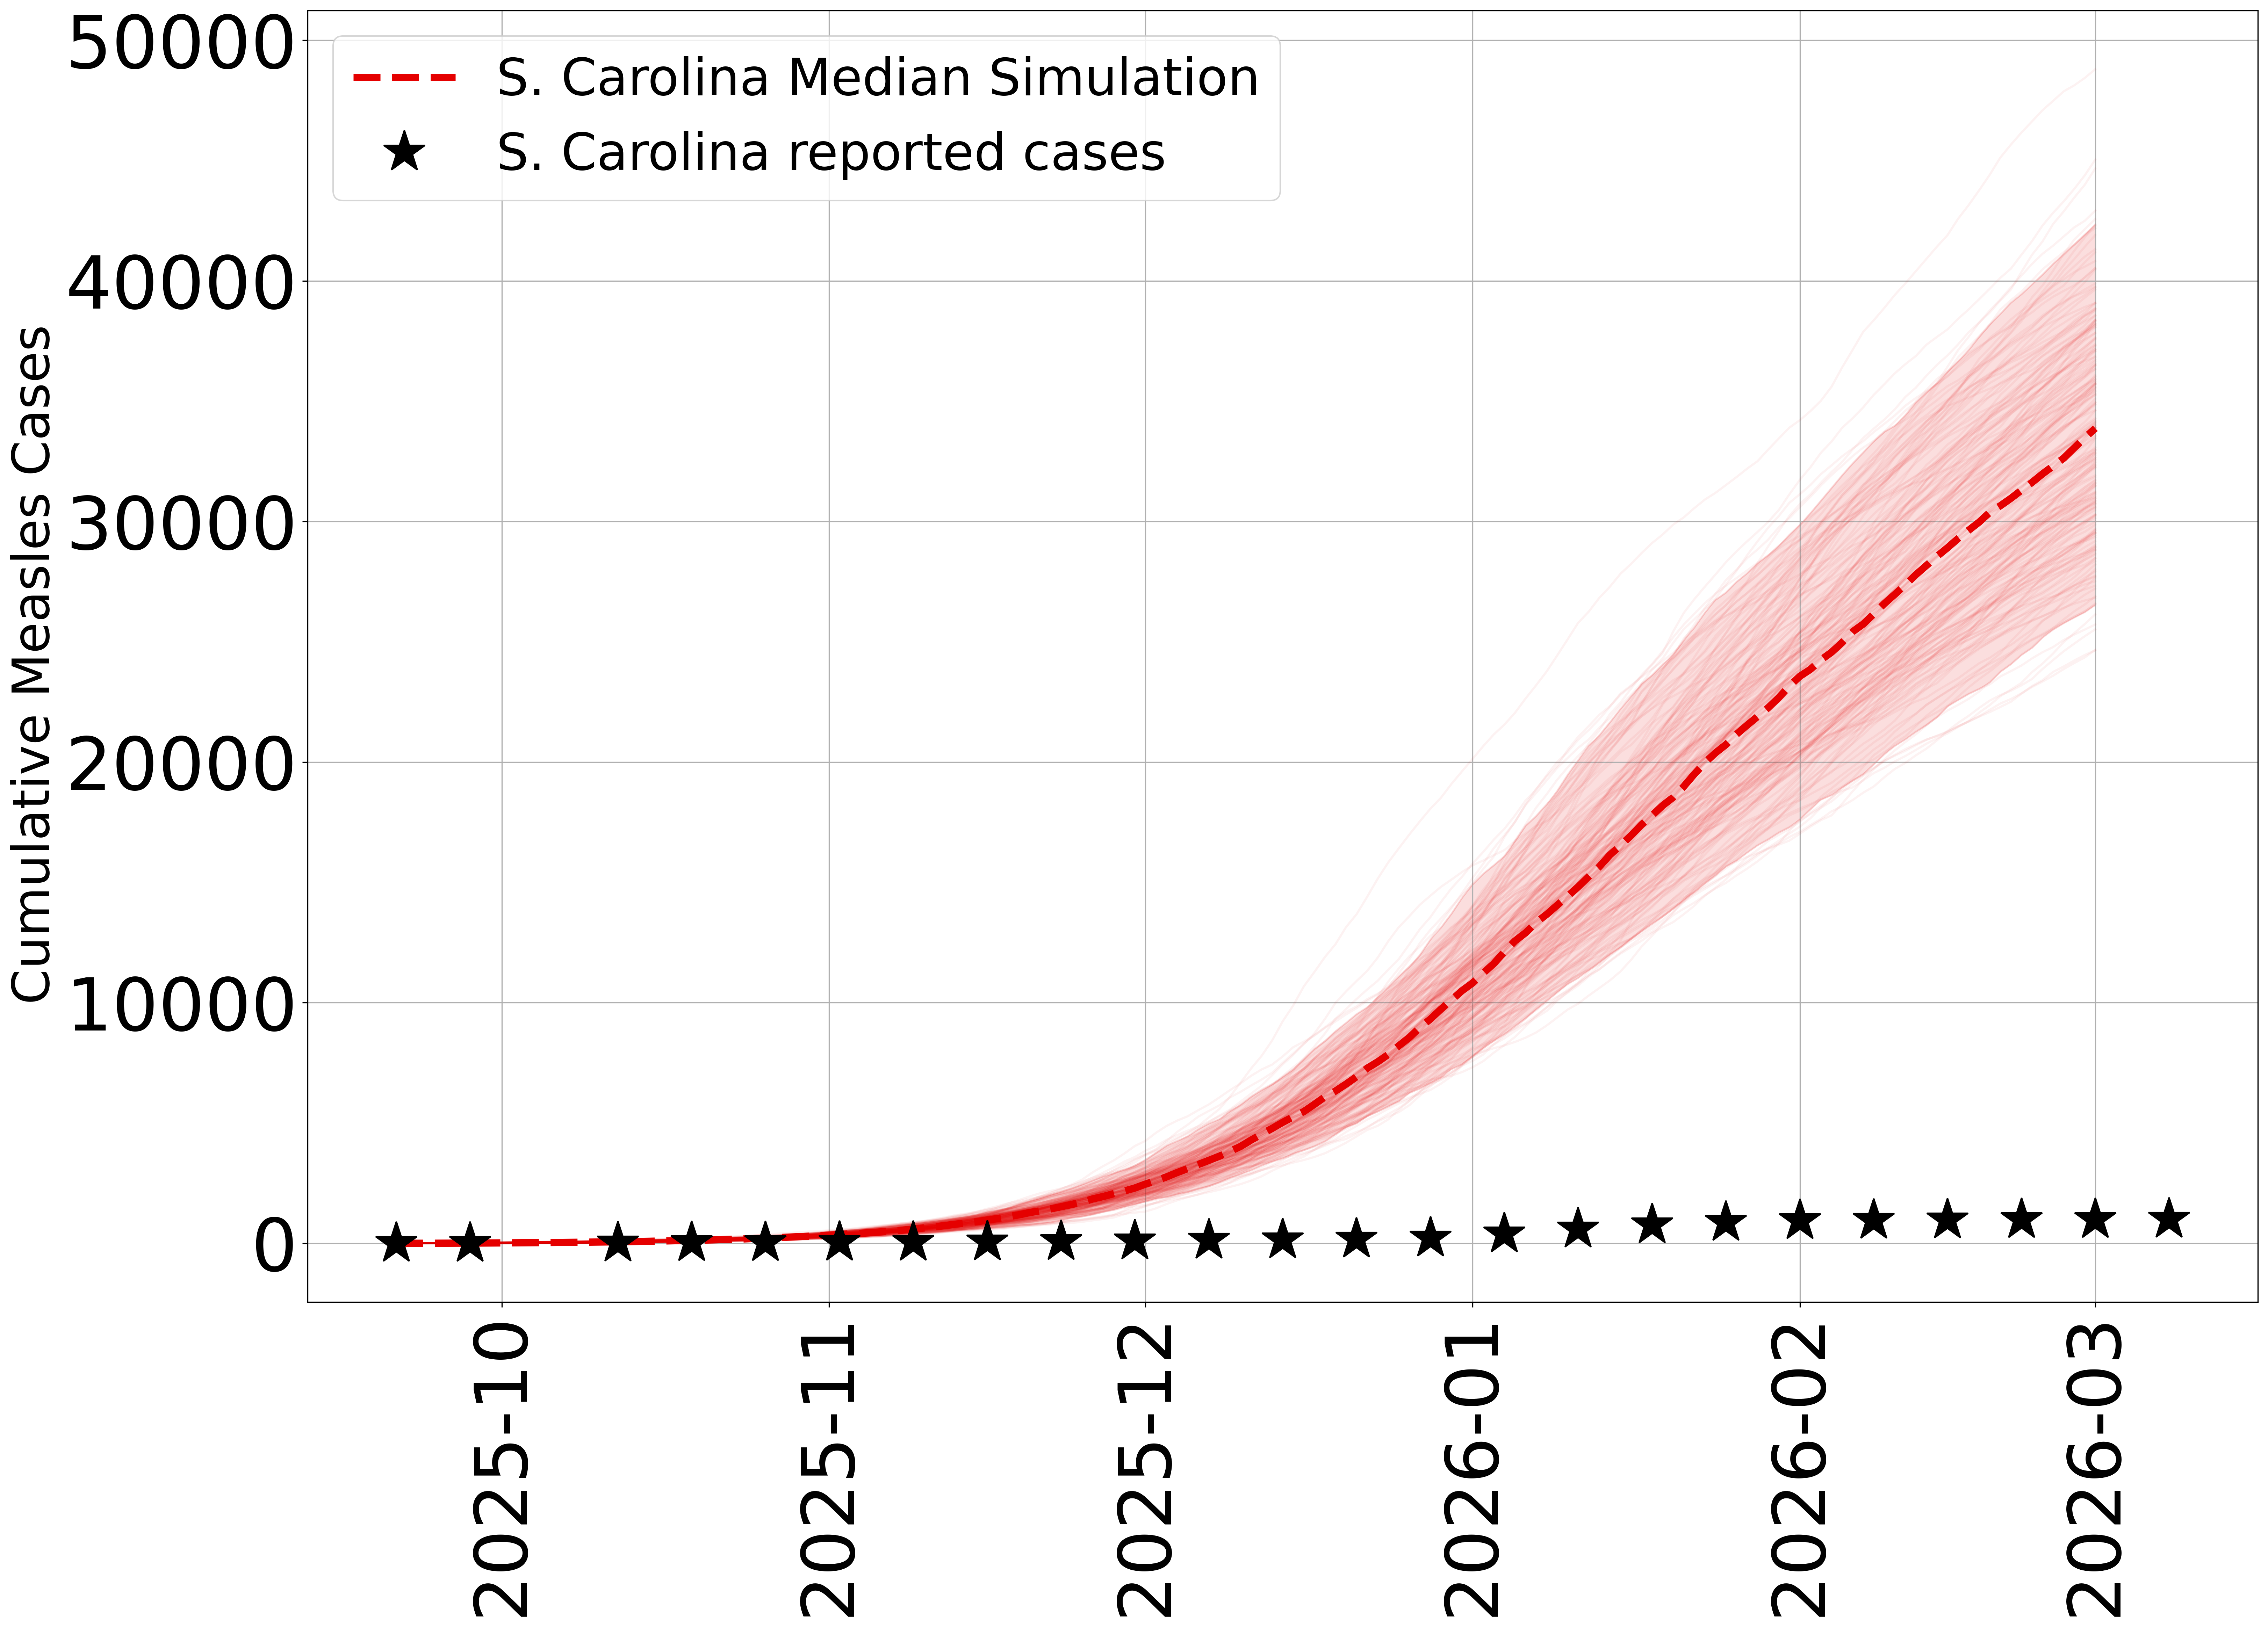

In [36]:
# all 200 trajectories
drange1 = pd.date_range("2025-09-21", periods=162, freq="1D")
fig = plt.figure(num=None, figsize=(24, 16), dpi=300, facecolor='w', edgecolor='k')
plt.rcParams.update({'font.size': 50})

# Plot 200 simulation trajectories (thin, light red lines)
for i in range(cum_Inf_A.shape[1]):
    plt.plot(drange1, cum_Inf_A[:, i], color='xkcd:red', alpha=0.05, linewidth=1.5)

plt.fill_between(drange1, cum_Inf_p_A[:,2], cum_Inf_p_A[:,22], color='xkcd:red', alpha=0.13)
plt.plot(drange1, cum_Inf_p_A[:,12], '--', color='xkcd:red', lw=5, label = 'S. Carolina Median Simulation')

dates = pd.to_datetime(GC['Update Date']).dt.to_pydatetime()
plt.plot(dates, GC['Cumulative Cases'], '*', color='black', markersize=30, label = 'S. Carolina reported cases')

plt.xticks(rotation=90)
plt.ylabel('Cumulative Measles Cases ', fontsize = 35)
plt.legend(fontsize=35,loc='upper left');
plt.grid()
plt.show()

In [42]:
try:
    print(f"Scenario A data shape: {cum_Inf_A.shape if 'cum_Inf_A' in globals() else 'Not Defined'}")
    print(f"Scenario B data shape: {cum_Inf_B.shape if 'cum_Inf_B' in globals() else 'Not Defined'}")
    print(f"Scenario C data shape: {cum_Inf_C.shape if 'cum_Inf_C' in globals() else 'Not Defined'}")
except Exception as e:
    print(f"Error accessing simulation variables: {e}")

Scenario A data shape: (162, 200)
Scenario B data shape: (162, 200)
Scenario C data shape: (162, 200)


In [43]:
fit_case, cumI, cumH, cumD, cumcase, cumhosp, cumdeath, cumcase0, cumhosp0, cumcase1, cumhosp1, cumcase2, cumhosp2 = sim_det(
            0, x1, x2, x3, z1, z2, z3, V_base, y1,y2,y3)

NameError: name 'gamma2_pe' is not defined

In [ ]:
fit_case, cumI, cumH, cumD, cumcase, cumhosp, cumdeath, cumcase0, cumhosp0, cumcase1, cumhosp1, cumcase2, cumhosp2 = sim_det(
            0, x1, x2, x3, z1, z2, z3, V_base, y1,y2,y3)

In [ ]:
fit_case, cumI, cumH, cumD, cumcase, cumhosp, cumdeath, cumcase0, cumhosp0, cumcase1, cumhosp1, cumcase2, cumhosp2 = sim_det(
            0, x1, x2, x3, z1, z2, z3, V_base, y1,y2,y3)

In [ ]:
print(cumcase0)

In [ ]:
drange1 = pd.date_range("2025-09-21", periods=162, freq="1D")
fig = plt.figure(num=None, figsize=(24, 16), dpi=300, facecolor='w', edgecolor='k')
plt.rcParams.update({'font.size': 50})

plt.plot(drange1, cumcase, '--', color='xkcd:red', lw=5, label = 'S. Carolina Vaccine Uptakes')


dates = pd.to_datetime(GC['Update Date']).dt.to_pydatetime()
plt.plot(dates, GC['Cumulative Cases'], '*', color='black', markersize=30, label = 'DSHS reported cases')

plt.xticks(rotation=90)
plt.ylabel('Cumulative Measles Cases ', fontsize = 35)
plt.legend(fontsize=35,loc='upper left');
plt.autoscale(enable=True, axis='x', tight=True)
plt.grid()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False) #plt.title('High protection') #plt.axis([18970, 19285, 0, 1e6]) #plt.ylabel('reported deaths')
plt.tight_layout()

In [ ]:
#only S. Carolina Vaccine Uptakes by age groups
drange1 = pd.date_range("2025-09-21", periods=162, freq="1D")
fig = plt.figure(num=None, figsize=(24, 16), dpi=300, facecolor='w', edgecolor='k')
plt.rcParams.update({'font.size': 50})

plt.plot(drange1, cumcase0, '--', color='xkcd:red', lw=5, label = 'Age0')
plt.plot(drange1, cumcase1, '--', color='xkcd:blue', lw=5, label = 'Age1')
plt.plot(drange1, cumcase2, '--', color='xkcd:green', lw=5, label = 'Age2')

dates = pd.to_datetime(GC['Update Date']).dt.to_pydatetime()
plt.plot(dates, y_case0, '*', color='red', markersize=30, label = 'Reported0')

dates = pd.to_datetime(GC['Update Date']).dt.to_pydatetime()
plt.plot(dates, y_case1, '*', color='blue', markersize=30, label = 'Reported1')

dates = pd.to_datetime(GC['Update Date']).dt.to_pydatetime()
plt.plot(dates, y_case2, '*', color='green', markersize=30, label = 'Reported2')

plt.xticks(rotation=90)
plt.ylabel('Cumulative Measles Cases ', fontsize = 35)
plt.legend(fontsize=35,loc='upper left');
plt.autoscale(enable=True, axis='x', tight=True)
plt.grid()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False) #plt.title('High protection') #plt.axis([18970, 19285, 0, 1e6]) #plt.ylabel('reported deaths')
plt.tight_layout()

In [ ]:
def sim_scenario(V_sce):
    Nsim = 200
    Nd = 162
    x1, x2, x3 = popt[0], popt[1], popt[2]
    y1, y2, y3 = popt[3], popt[4], popt[5]
    z1, z2, z3 = pcov[0][0], pcov[1][1], pcov[2][2]

    cum_Inf = np.zeros([Nd, Nsim])
    cum_Inf0, cum_Inf1, cum_Inf2 = [np.zeros([Nd, Nsim]) for _ in range(3)]

    for i in range(Nsim):
        _, _, _, _, cumcase, _, _, c0, _, c1, _, c2, _ = sim_sto(0, x1, x2, x3, z1, z2, z3, V_sce, y1, y2, y3)
        cum_Inf[:, i] = cumcase
        cum_Inf0[:, i] = c0
        cum_Inf1[:, i] = c1
        cum_Inf2[:, i] = c2

    percentiles = [0, 1, 2.5, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 97.5, 99, 100]
    res = []
    for arr in [cum_Inf, cum_Inf0, cum_Inf1, cum_Inf2]:
        res.append(np.percentile(arr, percentiles, axis=1).T)

    return (None, None, None, cum_Inf, res[0], None, None, res[1], res[2], res[3], None, None, None)

In [ ]:
new_Inf_p_A, _, _, cum_Inf_A, cum_Inf_p_A, _, _, cum_Inf0_p_A, cum_Inf1_p_A, cum_Inf2_p_A, _, _, _ = sim_scenario(V_base)
new_Inf_p_B, _, _, cum_Inf_B, cum_Inf_p_B, _, _, cum_Inf0_p_B, cum_Inf1_p_B, cum_Inf2_p_B, _, _, _ = sim_scenario(V_low)
new_Inf_p_C, _, _, cum_Inf_C, cum_Inf_p_C, _, _, cum_Inf0_p_C, cum_Inf1_p_C, cum_Inf2_p_C, _, _, _ = sim_scenario(V_high)
print("Scenarios updated with IDR logic.")

In [ ]:
# all 200 trajectories
drange1 = pd.date_range("2025-09-28", periods=162, freq="1D") # updated to match our data
fig = plt.figure(num=None, figsize=(24, 16), dpi=300, facecolor='w', edgecolor='k')
plt.rcParams.update({'font.size': 50})

# Plot 200 simulation trajectories (thin, light red lines)
for i in range(cum_Inf_A.shape[1]):  # updated to assume shape is (161, 200)
    plt.plot(drange1, cum_Inf_A[:, i], color='xkcd:red', alpha=0.05, linewidth=1.5)

plt.fill_between(drange1, cum_Inf_p_A[:,2], cum_Inf_p_A[:,22], color='xkcd:red', alpha=0.13)
plt.plot(drange1, cum_Inf_p_A[:,12], '--', color='xkcd:red', lw=5, label = 'S. Carolina Median Simulation')

dates = pd.to_datetime(GC['Update Date']).dt.to_pydatetime()
plt.plot(dates, GC['Cumulative Cases'], '*', color='black', markersize=30, label = 'S. Carolina reported cases')

plt.xticks(rotation=90)
plt.tick_params(axis='both', labelsize=35)
plt.ylabel('Cumulative Measles Cases ', fontsize = 35)
plt.setp(plt.gca().xaxis.get_majorticklabels(), rotation=45, ha="right")
plt.legend(fontsize=35,loc='upper left');
plt.autoscale(enable=True, axis='x', tight=True)
plt.grid()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False) #plt.title('High protection') #plt.axis([18970, 19285, 0, 1e6]) #plt.ylabel('reported deaths')
plt.tight_layout()

# Save the figure
output_path = os.path.join(FIGURE_DIR, "case_200.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')

In [ ]:
drange1 = pd.date_range("2025-09-28", periods=162, freq="1D")
fig = plt.figure(num=None, figsize=(24, 16), dpi=300, facecolor='w', edgecolor='k')
plt.rcParams.update({'font.size': 50})

plt.fill_between(drange1, cum_Inf_p_A[:,2], cum_Inf_p_A[:,22], color='xkcd:red', alpha=0.13)
plt.plot(drange1, cum_Inf_p_A[:,12], '--', color='xkcd:red', lw=5, label = 'S. Carolina Uptakes')

plt.fill_between(drange1, cum_Inf_p_B[:,2], cum_Inf_p_B[:,22], color='xkcd:blue', alpha=0.13)
plt.plot(drange1, cum_Inf_p_B[:,12], '--', color='xkcd:blue', lw=5, label = 'S. Carolina Uptakes (-5%)')

plt.fill_between(drange1, cum_Inf_p_C[:,2], cum_Inf_p_C[:,22], color='xkcd:blue', alpha=0.13)
plt.plot(drange1, cum_Inf_p_C[:,12], '--', color='xkcd:green', lw=5, label = 'S. Carolina Uptakes (+5%)')

dates = pd.to_datetime(GC['Update Date']).dt.to_pydatetime()
plt.plot(dates, GC['Cumulative Cases'], '*', color='black', markersize=30, label = 'S. Carolina reported cases')

plt.xticks(rotation=90)
plt.tick_params(axis='both', labelsize=35)
plt.ylabel('Cumulative Measles Cases ', fontsize = 35)
plt.legend(fontsize=35,loc='upper left');
plt.autoscale(enable=True, axis='x', tight=True)
plt.grid()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False) #plt.title('High protection') #plt.axis([18970, 19285, 0, 1e6]) #plt.ylabel('reported deaths')
plt.tight_layout()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Define the 1x2 subplot layout
fig, axs = plt.subplots(1, 2, figsize=(18,12), dpi=300, facecolor='w', edgecolor='k')

# Global font settings
plt.rcParams.update({'font.size': 30})  # Consistent large font for readability

# Define date range
drange1 = pd.date_range("2025-09-28", periods=162, freq="1D")

# --- First subplot: Cumulative Cases ---
ax = axs[0]

ax.fill_between(drange1, cum_Inf_p_A[:, 2], cum_Inf_p_A[:, 22], color='xkcd:red', alpha=0.13)
ax.plot(drange1, cum_Inf_p_A[:, 12], '--', color='xkcd:red', lw=5, label='S. Carolina Uptake')

ax.fill_between(drange1, cum_Inf_p_B[:, 2], cum_Inf_p_B[:, 22], color='xkcd:blue', alpha=0.13)
ax.plot(drange1, cum_Inf_p_B[:, 12], '--', color='xkcd:blue', lw=5, label='S. Carolina Uptakes (-5%)')

ax.fill_between(drange1, cum_Inf_p_C[:, 2], cum_Inf_p_C[:, 22], color='xkcd:green', alpha=0.13)
ax.plot(drange1, cum_Inf_p_C[:, 12], '--', color='xkcd:green', lw=5, label='Texas State Uptake (+5%)')

# Reported cases as black stars
dates = pd.to_datetime(GC['Update Date']).dt.to_pydatetime()
ax.plot(dates, GC['Cumulative Cases'], '*', color='black', markersize=15, label='S. Carolina Reported Cases')

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=30))  # Show every 15th day
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")  # Rotate for readability

ax.set_ylabel('Cumulative Measles Cases', fontsize=30)
ax.tick_params(axis='both', labelsize=25)
ax.legend(fontsize=20, loc='upper left', bbox_to_anchor=(-0.15, 1.15), borderaxespad=0.)
ax.grid(alpha=0.6)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Second subplot: Cumulative Hospitalizations ---
ax1 = axs[1]

ax1.fill_between(drange1, cum_Hosp_p_A[:, 2], cum_Hosp_p_A[:, 22], color='xkcd:red', alpha=0.13)
ax1.plot(drange1, cum_Hosp_p_A[:, 12], '--', color='xkcd:red', lw=5, label='S. Carolina Vaccine Uptakes')

ax1.fill_between(drange1, cum_Hosp_p_B[:, 2], cum_Hosp_p_B[:, 22], color='xkcd:blue', alpha=0.13)
ax1.plot(drange1, cum_Hosp_p_B[:, 12], '--', color='xkcd:blue', lw=5, label='S. Carolina Vaccine Uptakes (-5%)')

ax1.fill_between(drange1, cum_Hosp_p_C[:, 2], cum_Hosp_p_C[:, 22], color='xkcd:green', alpha=0.13)
ax1.plot(drange1, cum_Hosp_p_C[:, 12], '--', color='xkcd:green', lw=5, label='Texas State Vaccine Uptakes (+5%)')

# Format x-axis
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=30))  # Show every 15th day
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")  # Rotate for readability

ax1.set_ylabel('Cumulative Hospitalizations', fontsize=30)
ax1.tick_params(axis='both', labelsize=25)
#ax1.legend(fontsize=24, loc='upper left')
ax1.grid(alpha=0.6)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

plt.tight_layout()

# Save the figure
output_path = os.path.join(FIGURE_DIR, "case.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
#only S. Carolina Vaccine Uptakes by age groups
drange1 = pd.date_range("2025-09-28", periods=162, freq="1D")
fig = plt.figure(num=None, figsize=(24, 16), dpi=300, facecolor='w', edgecolor='k')
plt.rcParams.update({'font.size': 50})

plt.fill_between(drange1, cum_Inf0_p_A[:,2], cum_Inf0_p_A[:,22], color='xkcd:red', alpha=0.13)
plt.plot(drange1, cum_Inf0_p_A[:,12], '--', color='xkcd:red', lw=5, label = 'Age0-4')

plt.fill_between(drange1, cum_Inf1_p_A[:,2], cum_Inf1_p_A[:,22], color='xkcd:blue', alpha=0.13)
plt.plot(drange1, cum_Inf1_p_A[:,12], '--', color='xkcd:blue', lw=5, label = 'Age5-19')

plt.fill_between(drange1, cum_Inf2_p_A[:,2], cum_Inf2_p_A[:,22], color='xkcd:green', alpha=0.13)
plt.plot(drange1, cum_Inf2_p_A[:,12], '--', color='xkcd:green', lw=5, label = 'Age20+')

dates = pd.to_datetime(GC['Update Date']).dt.to_pydatetime()
plt.plot(dates, y_case0, '*', color='red', markersize=30, label = 'Reported0-4')

dates = pd.to_datetime(GC['Update Date']).dt.to_pydatetime()
plt.plot(dates, y_case1, '*', color='blue', markersize=30, label = 'Reported5-19')

dates = pd.to_datetime(GC['Update Date']).dt.to_pydatetime()
plt.plot(dates, y_case2, '*', color='green', markersize=30, label = 'Reported20+')

plt.xticks(rotation=90)
plt.ylabel('Cumulative Measles Cases ', fontsize = 35)
plt.legend(fontsize=35,loc='upper left');
plt.autoscale(enable=True, axis='x', tight=True)
plt.grid()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False) #plt.title('High protection') #plt.axis([18970, 19285, 0, 1e6]) #plt.ylabel('reported deaths')
plt.tight_layout()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
import os

os.makedirs(FIGURE_DIR, exist_ok=True)

fig, axs = plt.subplots(2, 2, figsize=(24, 20), dpi=300, facecolor='w', edgecolor='k')
plt.rcParams.update({'font.size': 50})

drange1 = pd.date_range("2025-09-28", periods=162, freq="1D")

# Top Left: Total Cases Comparison
ax = axs[0, 0]
ax.fill_between(drange1, cum_Inf_p_A[:, 2], cum_Inf_p_A[:, 22], color='xkcd:red', alpha=0.13)
ax.plot(drange1, cum_Inf_p_A[:, 12], '--', color='xkcd:red', lw=5, label='Baseline')
ax.fill_between(drange1, cum_Inf_p_B[:, 2], cum_Inf_p_B[:, 22], color='xkcd:blue', alpha=0.13)
ax.plot(drange1, cum_Inf_p_B[:, 12], '--', color='xkcd:blue', lw=5, label='Uptake -5%')
ax.fill_between(drange1, cum_Inf_p_C[:, 2], cum_Inf_p_C[:, 22], color='xkcd:green', alpha=0.13)
ax.plot(drange1, cum_Inf_p_C[:, 12], '--', color='xkcd:green', lw=5, label='Uptake +5%')

for a in axs.flat:
    a.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    a.xaxis.set_major_locator(mdates.DayLocator(interval=30))
    plt.setp(a.xaxis.get_majorticklabels(), rotation=45, ha="right", fontsize=20)
    a.grid(True, alpha=0.3)

ax.set_ylabel('Total Cases', fontsize=30)
ax.legend(fontsize=20)

axs[0, 1].plot(drange1, cum_Inf0_p_A[:, 12], color='red', label='Age 0-4')
axs[1, 0].plot(drange1, cum_Inf1_p_A[:, 12], color='blue', label='Age 5-19')
axs[1, 1].plot(drange1, cum_Inf2_p_A[:, 12], color='green', label='Age 20+')

plt.tight_layout()
plt.show()

In [ ]:
# Define the 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(24, 20), dpi=300, facecolor='w', edgecolor='k')
plt.rcParams.update({'font.size': 50})  # Keep font size consistent

# First subplot (Top-Left: Your current plot)
ax = axs[0, 0]

drange1 = pd.date_range("2025-09-28", periods=162, freq="1D")

ax.fill_between(drange1, cum_Hosp_p_A[:, 2], cum_Hosp_p_A[:, 22], color='xkcd:red', alpha=0.13)
ax.plot(drange1, cum_Hosp_p_A[:, 12], '--', color='xkcd:red', lw=5, label='S. Carolina Vaccine Uptakes')

ax.fill_between(drange1, cum_Hosp_p_B[:, 2], cum_Hosp_p_B[:, 22], color='xkcd:blue', alpha=0.13)
ax.plot(drange1, cum_Hosp_p_B[:, 12], '--', color='xkcd:blue', lw=5, label='S. Carolina Vaccine Uptakes decreased by 5%')

ax.fill_between(drange1, cum_Hosp_p_C[:,2], cum_Hosp_p_C[:,22], color='xkcd:blue', alpha=0.13)
ax.plot(drange1, cum_Hosp_p_C[:,12], '--', color='xkcd:green', lw=5, label = 'S. Carolina Vaccine Uptakes increased by 5%')

#dates = pd.to_datetime(GC['Update Date']).dt.to_pydatetime()
#ax.plot(dates, GC['Cumulative Cases'], '*', color='black', markersize=20, label='S. Carolina Reported Cases')

# Format x-axis to only show date
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Show only date
ax.xaxis.set_major_locator(mdates.DayLocator(interval=10))  # Show every 5th day (adjustable)
plt.setp(ax.xaxis.get_majorticklabels(), fontsize=20, rotation=90, ha="right")  # Rotate for readability
plt.setp(ax.yaxis.get_majorticklabels(), fontsize=20)

ax.set_ylabel('Cumulative Hospitalizations', fontsize=20)
#ax.legend(fontsize=20, loc='upper left')
ax.legend(fontsize=20, loc='upper left', bbox_to_anchor=(-0.05, 1.25), borderaxespad=0.)
ax.autoscale(enable=True, axis='x', tight=True)
ax.grid()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax1 = axs[0, 1]

ax1.fill_between(drange1, cum_Hosp0_p_A[:, 2], cum_Hosp0_p_A[:, 22], color='xkcd:red', alpha=0.13)
ax1.plot(drange1, cum_Hosp0_p_A[:, 12], '--', color='xkcd:red', lw=5, label='Baseline Vaccine Uptake')

ax1.fill_between(drange1, cum_Hosp0_p_B[:, 2], cum_Hosp0_p_B[:, 22], color='xkcd:blue', alpha=0.13)
ax1.plot(drange1, cum_Hosp0_p_B[:, 12], '--', color='xkcd:blue', lw=5, label='Annual Vaccine Uptake Reduced by 15%')

ax1.fill_between(drange1, cum_Hosp0_p_C[:,2], cum_Hosp0_p_C[:,22], color='xkcd:blue', alpha=0.13)
ax1.plot(drange1, cum_Hosp0_p_C[:,12], '--', color='xkcd:green', lw=5, label = 'Average vaccine uptake across Texas')

# Format x-axis to only show date
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Show only date
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=10))  # Show every 5th day (adjustable)
plt.setp(ax1.xaxis.get_majorticklabels(), fontsize=20, rotation=90, ha="right")  # Rotate for readability
plt.setp(ax1.yaxis.get_majorticklabels(), fontsize=20)

ax1.set_ylabel('Cumulative Hospitalizations 0-4', fontsize=20)
ax1.autoscale(enable=True, axis='x', tight=True)
ax1.grid()

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2 = axs[1, 0]

ax2.fill_between(drange1, cum_Hosp1_p_A[:, 2], cum_Hosp1_p_A[:, 22], color='xkcd:red', alpha=0.13)
ax2.plot(drange1, cum_Hosp1_p_A[:, 12], '--', color='xkcd:red', lw=5, label='Baseline Vaccine Uptake')

ax2.fill_between(drange1, cum_Hosp1_p_B[:, 2], cum_Hosp1_p_B[:, 22], color='xkcd:blue', alpha=0.13)
ax2.plot(drange1, cum_Hosp1_p_B[:, 12], '--', color='xkcd:blue', lw=5, label='Annual Vaccine Uptake Reduced by 5%')

ax2.fill_between(drange1, cum_Hosp1_p_C[:,2], cum_Hosp1_p_C[:,22], color='xkcd:blue', alpha=0.13)
ax2.plot(drange1, cum_Hosp1_p_C[:,12], '--', color='xkcd:green', lw=5, label = 'Average vaccine uptake across Texas')

# Format x-axis to only show date
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Show only date
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=10))  # Show every 5th day (adjustable)
plt.setp(ax2.xaxis.get_majorticklabels(), fontsize=20, rotation=90, ha="right")  # Rotate for readability
plt.setp(ax2.yaxis.get_majorticklabels(), fontsize=20)

ax2.set_ylabel('Cumulative Hospitalizations 5-19', fontsize=20)
ax2.autoscale(enable=True, axis='x', tight=True)
ax2.grid()

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

ax3 = axs[1, 1]

ax3.fill_between(drange1, cum_Hosp2_p_A[:, 2], cum_Hosp2_p_A[:, 22], color='xkcd:red', alpha=0.13)
ax3.plot(drange1, cum_Hosp2_p_A[:, 12], '--', color='xkcd:red', lw=5, label='Baseline Vaccine Uptake')

ax3.fill_between(drange1, cum_Hosp2_p_B[:, 2], cum_Hosp2_p_B[:, 22], color='xkcd:blue', alpha=0.13)
ax3.plot(drange1, cum_Hosp2_p_B[:, 12], '--', color='xkcd:blue', lw=5, label='Annual Vaccine Uptake Reduced by 15%')

ax3.fill_between(drange1, cum_Hosp2_p_C[:,2], cum_Hosp2_p_C[:,22], color='xkcd:blue', alpha=0.13)
ax3.plot(drange1, cum_Hosp2_p_C[:,12], '--', color='xkcd:green', lw=5, label = 'Average vaccine uptake across Texas')

# Format x-axis to only show date
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Show only date
ax3.xaxis.set_major_locator(mdates.DayLocator(interval=10))  # Show every 5th day (adjustable)
plt.setp(ax3.xaxis.get_majorticklabels(), fontsize=20, rotation=90, ha="right")  # Rotate for readability
plt.setp(ax3.yaxis.get_majorticklabels(), fontsize=20)

ax3.set_ylabel('Cumulative Hospitalizations 20+', fontsize=20)
ax3.autoscale(enable=True, axis='x', tight=True)
ax3.grid()

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Adjust layout for better spacing
plt.tight_layout()

# Save the figure
output_path = os.path.join(FIGURE_DIR, "hosp_age.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')

In [ ]:
######### Calculate the difference

In [ ]:
total_inf_A = cum_Inf_A[-1, :]
total_inf_B = cum_Inf_B[-1, :]
total_inf_C = cum_Inf_C[-1, :]

diff1 = total_inf_B - total_inf_A
diff2 = total_inf_A - total_inf_C

print(f"Difference (Lower Uptake vs Baseline) Median: {np.median(diff1):.1f} (95% CI: {np.percentile(diff1, 2.5):.1f}, {np.percentile(diff1, 97.5):.1f})")
print(f"Difference (Baseline vs Higher Uptake) Median: {np.median(diff2):.1f} (95% CI: {np.percentile(diff2, 2.5):.1f}, {np.percentile(diff2, 97.5):.1f})")

In [ ]:
# Summary stats
mean_diff2 = np.mean(diff2)
median_diff2 = np.median(diff2)
lower_ci2 = np.percentile(diff2, 2.5)
upper_ci2 = np.percentile(diff2, 97.5)

# Print results
print(f"Mean difference: {mean_diff2:.1f}")
print(f"Median difference: {median_diff2:.1f}")
print(f"95% CI: ({lower_ci2:.1f}, {upper_ci2:.1f})")